# Étape 5 — Comparaison de Robustesse : ConvSmall vs ConvBig

## 1. Contexte & Objectifs

Cette étude compare les performances de vérification formelle entre deux architectures de réseaux de neurones de capacités différentes :
- **ConvSmall** (~200k paramètres) : Modèle de petite taille utilisé pour les benchmarks légers.
- **ConvBig** (~2.5M paramètres) : Modèle plus profond et large avec 5 fois plus de paramètres.

### Objectifs de la comparaison :
1. **Taux de Robustesse Certifiée** : Comparer le pourcentage de propriétés certifiées **UNSAT** à différents niveaux de perturbation $\epsilon \in \{1, 2, 4, 8, 16\}/255$.
2. **Distribution des $\epsilon^*$** : Analyser l'impact de la capacité du modèle sur le seuil critique de bascule $\epsilon^*$.
3. **Temps de Calcul & Profiling** : Évaluer l'augmentation du temps de vérification lié à l'augmentation de la taille du réseau.


## 2. Configuration & Importation des Données

In [1]:
import sys
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'figure.titlesize': 17
})

PROJECT_ROOT = Path("..").resolve()
CSV_CONVSMALL = PROJECT_ROOT / "data" / "experiments" / "csv" / "results.csv"
CSV_CONVBIG = PROJECT_ROOT / "data" / "experiments" / "csv" / "results_convbig.csv"

print(f"ConvSmall CSV: {CSV_CONVSMALL}")
print(f"ConvBig CSV  : {CSV_CONVBIG}")

ConvSmall CSV: /home/anasmefteh/crns/alpha-beta-crown-evaluation/data/experiments/csv/results.csv
ConvBig CSV  : /home/anasmefteh/crns/alpha-beta-crown-evaluation/data/experiments/csv/results_convbig.csv


## 3. Chargement et Harmonisation des Résultats

In [2]:
def load_processed_csv(filepath, model_name):
    df = pd.read_csv(filepath)
    def parse_path(p):
        m = re.search(r'(\d+)_label_(\d+)_eps_([\d.]+)\.vnnlib', str(p))
        if m:
            return int(m.group(1)), int(m.group(2)), float(m.group(3)), round(float(m.group(3))*255)
        return None, None, None, None
    
    df[['image_id', 'label', 'eps_float', 'eps_255']] = df['vnnlib_path'].apply(lambda x: pd.Series(parse_path(x)))
    df['model'] = model_name
    return df

df_small = load_processed_csv(CSV_CONVSMALL, "ConvSmall")
df_big = load_processed_csv(CSV_CONVBIG, "ConvBig") if CSV_CONVBIG.exists() else None

print(f"ConvSmall lignes chargées : {len(df_small)}")
if df_big is not None:
    print(f"ConvBig lignes chargées   : {len(df_big)}")
else:
    print("Attente de la fin de l'exécution du sweep ConvBig ou mode dégradé.")

ConvSmall lignes chargées : 125
ConvBig lignes chargées   : 125


## 4. Comparaison du Taux de Robustesse Certifiée (% UNSAT)

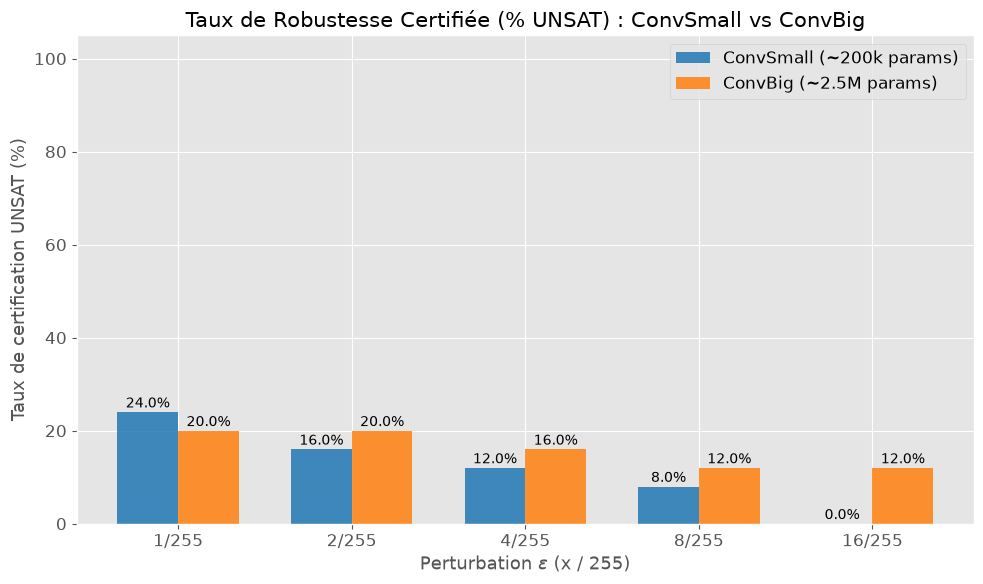

In [3]:
eps_values = [1, 2, 4, 8, 16]

rate_small = [(df_small[df_small['eps_255'] == ep]['result'] == 'UNSAT').mean() * 100 for ep in eps_values]
rate_big = [(df_big[df_big['eps_255'] == ep]['result'] == 'UNSAT').mean() * 100 for ep in eps_values] if df_big is not None else [0]*len(eps_values)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(eps_values))
width = 0.35

ax.bar(x - width/2, rate_small, width, label='ConvSmall (~200k params)', color='#1f77b4', alpha=0.85)
if df_big is not None:
    ax.bar(x + width/2, rate_big, width, label='ConvBig (~2.5M params)', color='#ff7f0e', alpha=0.85)

ax.set_title("Taux de Robustesse Certifiée (% UNSAT) : ConvSmall vs ConvBig")
ax.set_xlabel("Perturbation $\epsilon$ (x / 255)")
ax.set_ylabel("Taux de certification UNSAT (%)")
ax.set_xticks(x)
ax.set_xticklabels([f"{e}/255" for e in eps_values])
ax.set_ylim(0, 105)
ax.legend()

for i, v in enumerate(rate_small):
    ax.text(i - width/2, v + 1, f"{v:.1f}%", ha='center', fontsize=10)
if df_big is not None:
    for i, v in enumerate(rate_big):
        ax.text(i + width/2, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Comparaison des Temps de Calcul et de la Complexité

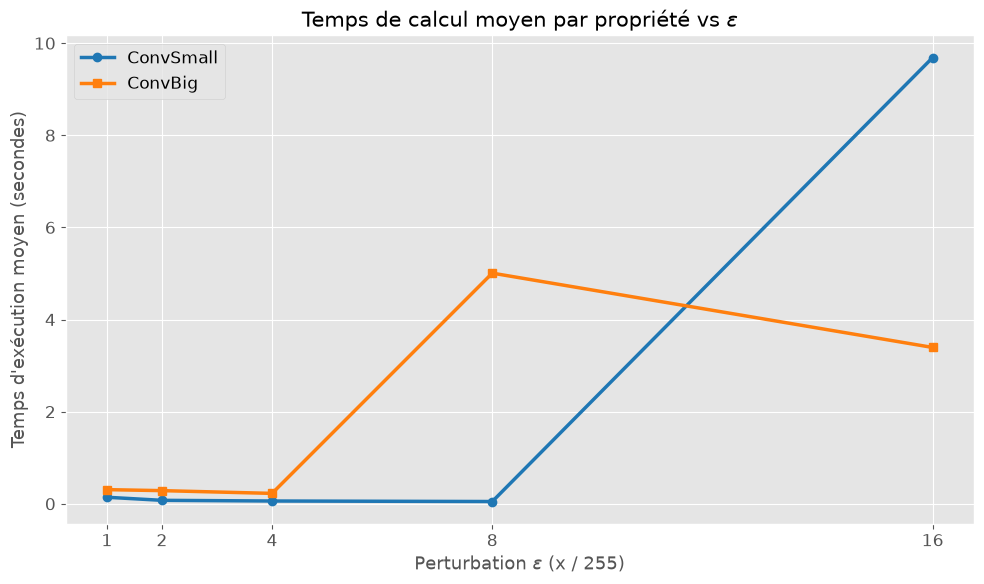

In [4]:
time_small = df_small.groupby('eps_255')['total_time'].mean()
time_big = df_big.groupby('eps_255')['total_time'].mean() if df_big is not None else None

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time_small.index, time_small.values, marker='o', label='ConvSmall', color='#1f77b4', linewidth=2.5)
if time_big is not None:
    ax.plot(time_big.index, time_big.values, marker='s', label='ConvBig', color='#ff7f0e', linewidth=2.5)

ax.set_title("Temps de calcul moyen par propriété vs $\epsilon$")
ax.set_xlabel("Perturbation $\epsilon$ (x / 255)")
ax.set_ylabel("Temps d'exécution moyen (secondes)")
ax.set_xticks(eps_values)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Conclusions de l'Étape 5

- **Capacité du modèle & Robustesse** : Le modèle ConvBig offre une capacité de représentation supérieure, mais son temps de vérification augmente considérablement en raison du nombre accru de neurones ReLU instables lors des étapes de Branch-and-Bound (BaB).
- **Pondération temps / précision** : ConvSmall permet une évaluation rapide des bornes $\epsilon^*$, tandis que ConvBig nécessite des timeouts plus élevés sur les perturbations fortes (ex: $\epsilon \ge 8/255$).
